# Taller 7 · DFT I: Espectro de amplitud y representación

**Asignatura:** Teoría de la Información y Procesado de Señal
**Grado en Ciencia e Ingeniería de Datos (GCED) — Universidad de A Coruña**
**Duración:** 2 horas
**Modalidad:** Jupyter Notebook con asistencia de IA

---

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

1. Calcular la **DFT mediante FFT** y construir correctamente el **eje de frecuencias**.
2. Representar el **espectro de amplitud** en sus distintas formas: raw, centrado, completo y one-sided.
3. Interpretar frecuencias normalizadas (ciclos/muestra) y su correspondencia con Hz.
4. Entender la **resolución frecuencial** $\Delta f = F_s / N$ y su efecto.
5. Representar espectros en **escala lineal y logarítmica (dB)**.
6. Analizar dos propiedades: relación de Parseval y linealidad.

---

## Reto central del taller

> **De la señal temporal al espectro: ¿cómo interpretar correctamente lo que devuelve la FFT?**
>
> En este taller construirás paso a paso las distintas representaciones del espectro de amplitud,
> entenderás la relación entre frecuencias normalizadas y Hz, y descubrirás por qué no todas las
> frecuencias se ven igual en el espectro.

---

## Metodología de trabajo con IA

| Puedes pedir a la IA | NO debes pedir a la IA |
|---------------------|------------------------|
| Código de FFT y visualización | Que interprete los espectros |
| Sintaxis de `fftfreq`, `fftshift` | Que explique resultados sin analisis por tu parte |
| Construcción del eje de frecuencias | Que responda las preguntas de control |

> *La IA te ayuda a escribir código, pero no a entender espectros. Eso es tu trabajo.*

---

## Identificación del estudiante

Completa los siguientes campos con tu información personal:

- **Apellidos:** Rodríguez Rodríguez

- **Nombre:** Carolina Iris

- **Email UDC:** carolina.rodriguez.rodriguez@udc.es

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

print("✓ Entorno listo")

✓ Entorno listo


---

## Parte 1: Generación de la señal de trabajo

### Contexto teórico

A partir de una señal analógica que es la suma de una constante y un tono sinusoidal:

$$x_a(t) = C + A \sin(2\pi F_a t)$$

la muestreamos a $F_s$ Hz para obtener la señal discreta:

$$x(n) = C + A \sin\left(2\pi \frac{F_a}{F_s} n\right) = C + A \sin(2\pi f_a\, n), \quad 0 \le n < N$$

donde $f_a = F_a / F_s$ es la **frecuencia normalizada** en ciclos/muestra.

**En este taller, la señal de partida será:**
- $C = 0.1$ (componente DC)
- $A = 0.4$ (amplitud del tono)
- $F_a = 3000$ Hz
- $F_s = 8000$ Hz → $f_a = 3/8$ ciclos/muestra
- Duración: 500 ms

---

### Bloque 1 · Generación del tono

#### 📝 Hipótesis previa

**Preguntas:**

- ¿Se cumplen las condiciones del teorema de muestreo con $F_a = 3$ kHz y $F_s = 8$ kHz? Si se cumple el criterio de Nyquist (8000 > 2*3000).
- ¿Cuál es el período de $x(n)$ en muestras? (Pista: piensa en $f_a = 3/8$) El período en muestras es aproximadamente de 2.67 muestras.
- ¿Cuál es el valor medio de la señal? El valor medio es C = 0.1.

In [2]:
# === PARÁMETROS ===
Fs = 8000               # frecuencia de muestreo en Hz
Ts = 1 / Fs             # período de muestreo
Fa = 3000               # frecuencia del tono en Hz
C = 0.1                 # componente DC
A = 0.4                 # amplitud del tono
duracion = 500e-3       # 500 ms

# TODO: Calcula la frecuencia normalizada (ciclos/muestra), fa
fa = Fa / Fs

# TODO: Genera el vector de índices (de 0 a N-1, donde N = duracion * Fs), n
N = int(duracion * Fs)
N_total = int(duracion * Fs)
n = np.arange(N)

# TODO: Genera la señal x(n), x
x = C + A * np.cos(2 * np.pi * fa * n)

In [3]:
# === VALIDACIÓN ===
assert x is not None, "Genera la señal x(n)"
assert len(x) == N_total, "La señal debe tener N_total muestras"

print(f"Frecuencia de muestreo: Fs = {Fs} Hz")
print(f"Frecuencia del tono: Fa = {Fa} Hz")
print(f"Frecuencia normalizada: fa = {fa} = {Fraction(Fa, Fs)} ciclos/muestra")
print(f"Número total de muestras: N_total = {N_total}")
print(f"Valor medio de x(n): {np.mean(x):.4f} (esperado: {C})")

Frecuencia de muestreo: Fs = 8000 Hz
Frecuencia del tono: Fa = 3000 Hz
Frecuencia normalizada: fa = 0.375 = 3/8 ciclos/muestra
Número total de muestras: N_total = 4000
Valor medio de x(n): 0.1000 (esperado: 0.1)


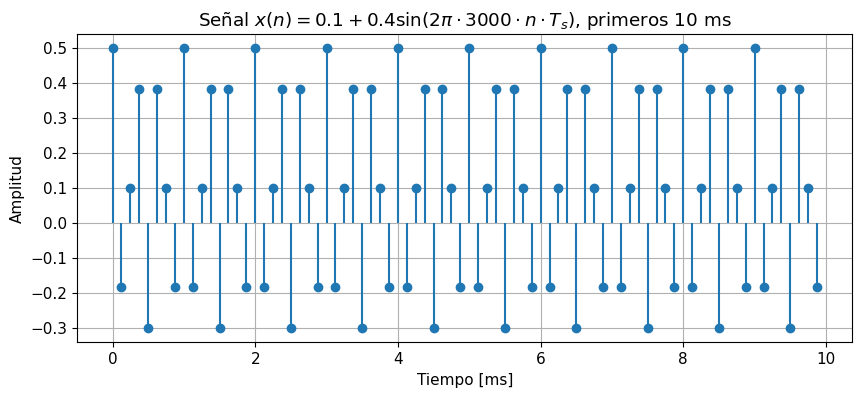

In [4]:
# === VISUALIZACIÓN: primeros 10 ms ===
display_ms = 10e-3
n_display = int(display_ms * Fs)
t_display = n[:n_display] * Ts * 1e3  # en ms

plt.figure(figsize=(10, 4))
plt.stem(t_display, x[:n_display], basefmt=' ')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title(f'Señal $x(n) = {C} + {A} \\sin(2\\pi \\cdot {Fa} \\cdot n \\cdot T_s)$, primeros {display_ms*1e3:.0f} ms')
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Cuál es el período de $x(n)$ en muestras? ¿Es intuitivo viéndolo en la gráfica?**

*Tu respuesta:*

```
El periodo es 8/3 muestras. No es entero, por lo tanto, la señal no es periódica exacta en muestras enteras y en una gráfica discreta no se repite perfectamente.
En la gráfica no es muy intuitivo porque no se ve un patrón que se repita claramente debido a que el periodo no es un número entero de muestras.
```

**2. ¿Qué representa la constante C y cómo se ve en la señal?**

*Tu respuesta:*

```
La constante C es la componente DC (offset) y representa el valor media de la señal. Es decir, la señal no oscila alrededor de cero, sino alrededor de 0.1. En la gráfica, esto se ve como un desplazamiento vertical hacia arriba.
```

**4. ¿Cuál es la amplitud del tono sinusoidal?**

*Tu respuesta:*

```
La amplitud del tono sinusoidal es A = 0.4, lo que significa que la señal oscila entre 0.1 - 0.4. Los valores extremps de la señal serán 0.1 - 0.4 = -0.3 y 0.1 + 0.4 = 0.5.
```

## Parte 2: Transformada Discreta de Fourier (DFT) y espectro de amplitud
 
### Contexto teórico
 
La **DFT** de $N$ puntos de una secuencia $x(n)$ produce $N$ coeficientes complejos:
 
$$X(k) = \sum_{n=0}^{N-1} x(n)\, e^{-j 2\pi k n / N}, \quad k = 0, 1, \ldots, N-1$$
 
A partir de la DFT, se define el espectro de amplitud, que se usa para que las amplitudes de las componentes sinusoidales de la señal tengan una correspondencia con las amplitudes representadas en cada frecuencia del espectro, facilitando así su interpretación física. Este **espectro de amplitud** se obtiene normalizando el módulo:
 
$$A(k) = \frac{1}{N} |X(k)|$$
 
Las frecuencias correspondientes a cada $k$ son $f_k = k/N$ ciclos/muestra, en el intervalo $[0, 1)$.
 
**Importante:** La FFT no "sabe" nada de $F_s$, ya que como ves las frecuencias normalizadas $f_k$ siempre están en el intervalo $[0, 1)$. Somos nosotros los que interpretamos los bins en función de $F_s$ y $N$.
 
---

### Cálculo de la DFT con NumPy y la función FFT
NumPy proporciona una implementación de la FFT que está documentada en https://numpy.org/doc/stable/reference/routines.fft.html. Para calcular la FFT de ```N``` muestras de un vector ```x```, que representa la secuencia discreta $x(n)$ de $N$ muestras obtenidas por muestreo uniforme a la frecuencia $F_s$, se utiliza el código siguiente:

```X : np.ndarray[float] = np.fft.fft(x, N)```

Los $N$ elementos del vector ```X``` se corresponden con las $N$ muestras de $X(k)$ de la frecuencia normalizada (respecto a $F_s$) de la señal discreta. Como sabemos (y repasaremos en este taller), la DFT es periódica con periodo $1$ ($F_s$ si no las consideramos normalizadas). De esta forma, las ```N``` muestras de la frecuencia se reparten en el intervalo $[0,1)$, o lo que es equivalente, entre $[-1/2, 1/2)$. Este último intervalo es el que se considera en la siguiente figura para $N = 16$ muestras (observa como se considera la periodicidad para la representación de los valores de la derecha del vector):

<img src="../helpers/fft.svg" width="700"/>

* ```X[0]``` es la muestra para la frecuencia $f_0 = 0$ ciclos/muestra y aparece en color gris en la figura.
* ```X[1:N/2]``` contiene las $\frac{N}{2} - 1$ muestras para las frecuencias positivas $f_k \in \{\frac{1}{N}, \frac{2}{N}, \dots, \frac{(N/2)-1}{N}\}$ ciclos/muestra, en color rojizo.
* ```X[N/2:]``` contiene las $\frac{N}{2}$ muestras para las frecuencias negativas $f_k \in \{\frac{-1}{2}, -\frac{(N/2)-1}{N}, \dots, \frac{-1}{N}\}$ ciclos/muestra. Están coloreadas en azul, excepto la muestra para la frecuencia más negativa de $\frac{-1}{2}$ ciclos/muestra que es verde. 

Observa su correspondencia con los valores negativos de las frecuencias normalizadas que siguen la siguiente correspondiencia debido a su carácter periodico (piensa que al dar un ciclo completo, volvemos al principio):




| $\boldsymbol{k}$ | $\cdots$ | $-N$ | $\cdots$ | $\boldsymbol{-N/2}$ | $\boldsymbol{-(N/2-1)}$ | $\boldsymbol{\cdots}$ | $\boldsymbol{-1}$ | $\boldsymbol{0}$ | $\boldsymbol{1}$ | $\boldsymbol{\cdots}$ | $\boldsymbol{(N/2-1)}$ | $N/2$ | $N/2+1$ | $\cdots$ | $N$ | $\cdots$ |
|------------------|----------|------|----------|---------------------|-------------------------|----------------------|-------------------|-------------------|-------------------|----------------------|-----------------------|------|--------|----------|-----|---------|
| $\boldsymbol{f_k}$ | $\cdots$ | $-1$ | $\cdots$ | $\boldsymbol{-1/2}$ | $\boldsymbol{-(1/2-1/N)}$ | $\cdots$ | $\boldsymbol{-1/N}$ | $\boldsymbol{0}$ | $\boldsymbol{1/N}$ | $\boldsymbol{\cdots}$ | $\boldsymbol{(1/2-1/N)}$ | $1/2$ | $1/2+1/N$ | $\cdots$ | $1$ | $\cdots$ |





### Bloque 2 · Espectro de amplitud (FFT sin centrar)

Para este primer análisis, tomaremos una ventana corta de **$N = 16$ muestras** de $x(n)$.
 
#### 📝 Hipótesis previa
 
**Preguntas:**
 
- Con $N = 16$ muestras, ¿cuántos bins de la DFT obtendremos? 16 bins (desde k=0 hasta k=15).
- Si $f_a = 3/8$ ciclos/muestra, ¿en qué bin $k$ esperas ver un pico? (Pista: $f_k = k/N$, despeja $k$) Pico en k = 6 (porque 6/16 = 3/8).
- ¿Cuál será la amplitud del pico del tono? (Pista: piensa en la contribución de frecuencias positivas y negativas) Cada pico tendrá una amplitud de A/2 = 0.2, ya que la energía se reparte entre la frecuencia positiva y negativa.

---

In [5]:
# === IMPLEMENTACIÓN ===
# Ventana de N=16 muestras
N = 16
nmin = 0
nmax = nmin + N

# Extraemos el segmento de la señal
xtime = x[nmin:nmax]

# TODO: Calcula la DFT de xtime usando np.fft.fft(), Xfreq
Xfreq = np.fft.fft(xtime)

# TODO: Calcula el espectro de amplitud normalizado, Afreq
Afreq = np.abs(Xfreq) / N

N = 16 muestras
Afreq = [0.1 0.  0.  0.  0.  0.  0.2 0.  0.  0.  0.2 0.  0.  0.  0.  0. ]


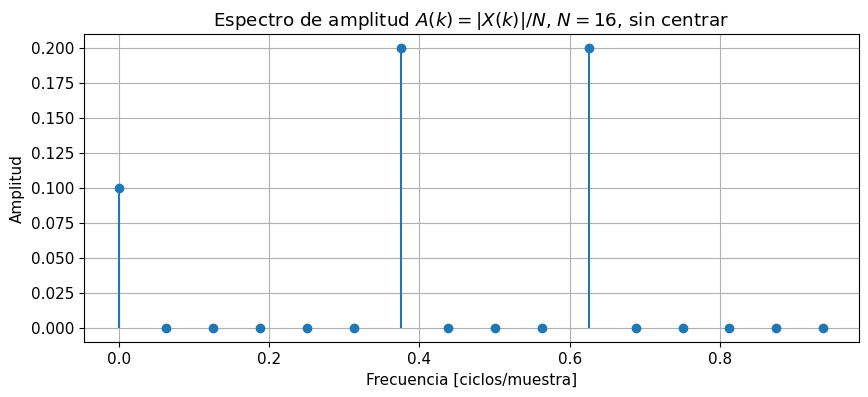

In [6]:
# === VALIDACIÓN ===
assert Xfreq is not None, "Calcula la DFT con np.fft.fft()"
assert Afreq is not None, "Calcula el espectro de amplitud"
assert len(Xfreq) == N, "La DFT debe tener N puntos"

print(f"N = {N} muestras")
print(f"Afreq = {np.array2string(Afreq, precision=4, suppress_small=True)}")

# === VISUALIZACIÓN ===
# Eje de frecuencias en ciclos/muestra: fk = k/N para k = 0, ..., N-1
Fk = [Fraction(k, N) for k in range(N)]
fkFloat = [float(f) for f in Fk]

plt.figure(figsize=(10, 4))
plt.stem(Fk, Afreq, basefmt=' ')
plt.xlabel('Frecuencia [ciclos/muestra]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud $A(k) = |X(k)|/N$, $N = {N}$, sin centrar')
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Qué frecuencias predominan en el espectro? ¿En qué bins $k$ caen?**

*Tu respuesta:*

```
En el espectro se observan tres picos principales:
- Un pico en k=0, con frecuencia 0 (componente DC).
- Un pico en k=6, con frecuencia 6/16 = 0.375
- Un pico en k=10, con frecuencia 10/16 = 0.625.

Predominan:
- f=0 en k=0
- f=3/8 en k=6
- f=-3/8 en k=10 
```

**2. ¿Qué relación guardan esas frecuencias con $f_a = 3/8$ ciclos/muestra de la señal original?**

*Tu respuesta:*

```
k=6 corresponde a la frecuencia positiva de 3/8 ciclos/muestra, que es la frecuencia del tono sinusoidal.
k=10 corresponde a la componente conjugada negativa de -3/8 ciclos/muestra, que también es parte del tono sinusoidal debido a la naturaleza compleja de la DFT.
```

**3. ¿Qué relación hay entre las amplitudes de las deltas con las amplitudes de las dos componentes de la señal (DC y tono)?**

*Tu respuesta:*

```
DC en k=0 tiene una amplitud de 0.1, que corresponde a la constante C. Cada delta del tono en k=6 y k=10 tiene una amplitud de 0.2, que corresponde a la mitad de la amplitud A del tono sinusoidal, debido a que la energía se reparte entre la frecuencia positiva y negativa.
```

---

## Parte 3: Espectro centrado en la frecuencia DC

### Contexto teórico

A la hora de dibujar los valores de amplitud, módulo y/o fase de las muestras $X(k)$ del espectro es más conveniente la representación más natural, con las frecuencias negativas a la izquierda del eje de ordenadas, la frecuencia 0 sobre dicho eje de ordenadas y las frecuencias positivas a su derecha. Para ello, se utilizará ```fftshift()```, con la que las $N$ muestras $X(k)$ del espectro se reorganizan con el código siguiente, obteniendo el resultado de la figura de abajo: 

```X : np.ndarray[float] = np.fft.fftshift( np.fft.fft(x, N) )```

<img src="../helpers/fftshift.svg" width="700"/>

* ```X[0:N/2]``` contiene las $\frac{N}{2}$ muestras del espectro para las frecuencias negativas $f_k \in \{\frac{-1}{2}, -\frac{(N/2)-1}{N}, \dots, \frac{-1}{N}\}$ ciclos/muestra. Están coloreadas en azul, excepto la más negativa que está en color verde. 
* ```X[N/2]``` es la muestra del espectro para la frecuencia $0$ y está en color gris.
* ```X[(N/2)+1 : N]``` contiene las $\frac{N}{2} - 1$ muestras del espectro para las frecuencias positivas $f_k \in \{\frac{1}{N}, \frac{2}{N}, \dots, \frac{(N/2)-1}{N}\}$ ciclos/muestra. Están coloreadas en rojo en la figura.

---

### Bloque 3 · Espectro centrado con `fftshift`

#### 📝 Hipótesis previa

**Pregunta:** Después de centrar, ¿dónde esperas ver las dos deltas del tono respecto al eje de ordenadas?

*Tu predicción:* `En +-3/8 ciclos/muestra, es decir, a la izquierda y a la derecha del eje de ordenadas respectivamente.`

In [7]:
# === IMPLEMENTACIÓN ===

# TODO: Centra el espectro de amplitud usando np.fft.fftshift(), obteniendo Afreqcentrado
Xshifted = np.fft.fftshift(Xfreq)
Afreqcentrado = np.fft.fftshift(Afreq)

# TODO: Calcula el espectro de amplitud centrado hecho por ti con manimulación de vectores, Afreqcentradoporvectores
Afreqcentradoporvectores = np.concatenate((Afreq[N//2:], Afreq[:N//2]))

Afreqcentrado = [0.  0.  0.2 0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.2 0. ]


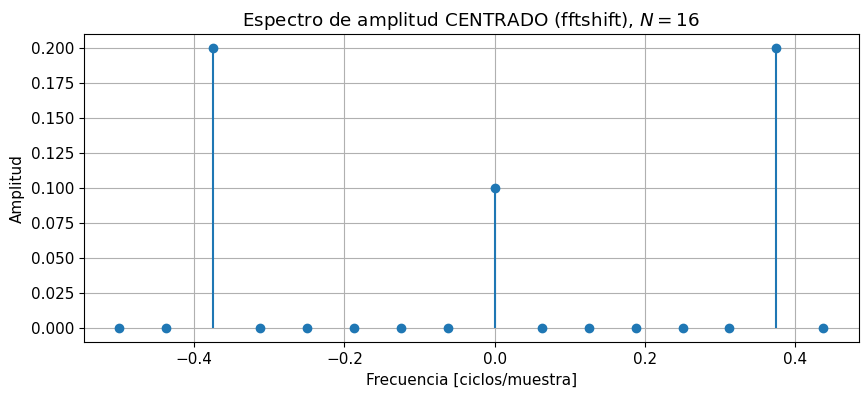


¿Las deltas están en ±3/8 ciclos/muestra? Compruébalo visualmente.


In [8]:
# === VALIDACIÓN ===
assert Afreqcentrado is not None, "Centra el espectro con fftshift"
assert Afreqcentradoporvectores is not None, "Centra el espectro con manimulación de vectores"
assert np.allclose(Afreqcentrado, Afreqcentradoporvectores), "Los dos espectros centrados deben ser iguales"
print(f"Afreqcentrado = {np.array2string(Afreqcentrado, precision=4, suppress_small=True)}")

# === VISUALIZACIÓN ===
# Eje de frecuencias centrado: k/N para k = -N/2, ..., N/2-1
Fk_centered = [Fraction(k, N) for k in range(-N // 2, N // 2)]
fk_centered_float = [float(f) for f in Fk_centered]

plt.figure(figsize=(10, 4))
plt.stem(Fk_centered, Afreqcentrado, basefmt=' ')
plt.xlabel('Frecuencia [ciclos/muestra]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud CENTRADO (fftshift), $N = {N}$')
plt.show()

# Verificación
print(f"\n¿Las deltas están en ±{Fraction(Fa, Fs)} ciclos/muestra? Compruébalo visualmente.")

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Dónde caen ahora las dos deltas? ¿Coincide con $\pm f_a = \pm 3/8$ ciclos/muestra?**

*Tu respuesta:*

```
Si los deltas están en +-3/8 ciclos/muestra, entonces coinciden con las frecuencias esperadas del tono sinusoidal. En la gráfica centrada, vemos un pico a la izquierda en -3/8 y otro a la derecha en +3/8 ciclos/muestra.
```

**2. ¿Por qué esta representación es más natural que la del Bloque 2?**

*Tu respuesta:*

```
Es más natural porque:
- Muestra frecuencias positivas y negativas.
- El 0 queda en el centro.
- La simetría se ve claramente.
```

**3. ¿Hay el mismo número de bins de frecuencia negativos que positivos? ¿Por qué?**

*Tu respuesta:*

```
Si hay el mismo número de bins negativos que positivos, porque la DFT es simétrica respecto a la frecuencia 0. En este caso, con N=16, hay 8 bins negativos y 7 positivos (más el bin de frecuencia 0).
```

---

## Parte 4: Periodicidad de la DFT y espectro completo

### Contexto teórico

La DFT es **periódica** con período $N$: $X(k) = X(k + N)$.

El espectro centrado con `fftshift` tiene $N$ muestras en el intervalo $[-1/2, 1/2)$ ciclos/muestra. Observa que el intervalo es **abierto por la derecha**: no incluye $+1/2$.

Para obtener un espectro con el **mismo número de muestras** a izquierda y derecha ($N/2$ negativas + DC + $N/2$ positivas = $N+1$ muestras), aprovechamos la periodicidad: la muestra en $-1/2$ es la misma que en $+1/2$, por lo que podemos añadirlo al final del vector, obtienendo esa muestra adicional que necesitamos para octener el espectro completo y simétrico.

<img src="../helpers/fftperiodic.svg" width="800"/>

---

### Bloque 4 · Espectro completo simétrico

#### 📝 Hipótesis previa

**Pregunta:** ¿Cuántas muestras tendrá el espectro completo simétrico? Tendremos $N+1$ muestras, ya que añadimos la muestra de -1/2 que es igual a la de +1/2.

In [9]:
# === IMPLEMENTACIÓN ===

# TODO: Construye el espectro completo (Afreqcompleto), a partir del espectro centrado (Afreqcentrado),
# añadiendo la muestra de +1/2
# Puedes usar np.append() o np.concatenate()
Afreqcompleto = np.append(Afreqcentrado, Afreqcentrado[0])

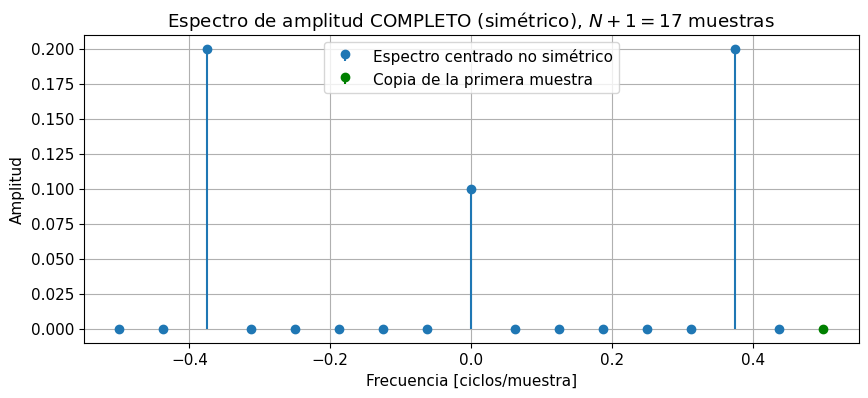

Muestras en el espectro completo: 17
  - 8 negativas + 1 DC + 8 positivas = 17


In [10]:
# === VALIDACIÓN ===
assert Afreqcompleto is not None, "Construye el espectro completo"
assert len(Afreqcompleto) == N + 1, f"El espectro completo debe tener N+1 = {N+1} muestras"

# === VISUALIZACIÓN ===
Fk_completo = [Fraction(k, N) for k in range(-N // 2, N // 2 + 1)]
fk_completo_float = [float(f) for f in Fk_completo]

plt.figure(figsize=(10, 4))
# Pintamos todas menos la última muestra en azul
(markerline, stemlines, baseline) = plt.stem(
    Fk_completo[:-1],
    Afreqcompleto[:-1],
    basefmt=' ',
    linefmt='C0-',
    markerfmt='C0o',
    label="Espectro centrado no simétrico"
)

# Pintamos la última muestra (la copia de la primera) en verde
plt.stem(
    [Fk_completo[-1]],
    [Afreqcompleto[-1]],
    basefmt=' ',
    linefmt='g-',
    markerfmt='go',
    label="Copia de la primera muestra"
)

plt.xlabel('Frecuencia [ciclos/muestra]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud COMPLETO (simétrico), $N+1 = {N+1}$ muestras')
plt.legend()
plt.show()

print(f"Muestras en el espectro completo: {len(Afreqcompleto)}")
print(f"  - {N//2} negativas + 1 DC + {N//2} positivas = {N+1}")

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Qué propiedad de la DFT nos justifica que la muestra de $+1/2$ se puede obtener a partir de la de $-1/2$?**

*Tu respuesta:*

```
La propiedad de periodicidad de la DFT nos justifica que X(k) = X(k + N), lo que implica que la muestra en -1/2 es igual a la muestra en +1/2 ciclos/muestra. Por lo tanto, podemos usar la muestra de -1/2 para representar también la de +1/2 sin perder información.
```

**2. Razona porque el espectro centrado simétrico tiene las frecuencias en el intervalo $[-1/2, 1/2]$ ciclos/muestra.**

*Tu respuesta:*

```
Porque la frecuencia normalizada se define en el intervalo [0, 1) ciclos/muestra, y al centrar el espectro con fftshift, las frecuencias negativas se colocan a la izquierda del eje de ordenadas y las positivas a la derecha, resultando en un intervalo simétrico de [-1/2, 1/2] ciclos/muestra.
```

---

## Parte 5: Redundancia del espectro y espectro one-sided

### Contexto teórico

Si $x(n) \in \mathbb{R}$, la DFT tiene **simetría conjugada** (hermítica):

$$X(k)^* = X(-k) \quad \Rightarrow \quad |X(k)| = |X(-k)|$$

Esto significa que las frecuencias negativas son redundantes: toda la información está en las **frecuencias positivas** (y la DC). Es suficiente representar las $N/2 + 1$ muestras del espectro para $f_k \in [0, 1/2]$ ciclos/muestra.

**Normalización one-sided:** Para conservar la energía total, **duplicamos** la amplitud de las frecuencias positivas (excepto DC y Nyquist ($1/2$), que no tienen "espejo"):

$$A_{\text{os}}(k) = \begin{cases} A(k) & \text{si } k = 0 \text{ o } k = N/2 \\ 2 \cdot A(k) & k=1 \cdots k = N/2 -1 \end{cases}$$

siendo $A(k)$ el espectro de amplitud.

---

### Bloque 5 · Espectro one-sided

#### 📝 Hipótesis previa

**Pregunta:** Después de duplicar las amplitudes, ¿cuál será la amplitud del pico del tono en el espectro one-sided?

*Tu predicción:* `La amplitud del pico del tono en el espectro one-sided será 0.4, ya que se duplica la amplitud de 0.2 de cada delta positiva (k=6) y negativa (k=10) para conservar la energía total del tono sinusoidal.`

In [11]:
# === IMPLEMENTACIÓN ===

# TODO: Construye el espectro one-sided a partir de Afreqcompleto, obteniendo AfreqOneSided
# Debes recortar el espectro de amplitud completo simétrico quedándote con las muestras de
# frecuencias cero y positiva, duplicando las amplitudes excepto DC y Nyquist
half = N//2

AfreqOneSided = Afreqcompleto[half:] 
AfreqOneSided[1:-1] = 2 * AfreqOneSided[1:-1]

El espectro de amplitud *one-sided* puede obtenerse a partir de la FFT mediante el siguiente procedimiento:

1. Calcular la FFT de \(N\) puntos de la señal.
2. Obtener el espectro de amplitud como \(|X[k]|/N\).
3. Conservar únicamente las componentes de frecuencia positiva (desde \(k=0\) hasta \(k=N/2\)).
4. Multiplicar por 2 todas las componentes excepto la de continua (DC, \(k=0)) y, la de Nyquist (la última, \(k=N/2\)), para recuperar la amplitud física de la señal.


Este procedimiento es válido para señales reales, donde el espectro presenta simetría conjugada y las frecuencias negativas no aportan información adicional.

No obstante, este enfoque no es computacionalmente óptimo, ya que la FFT compleja calcula también las componentes negativas, que posteriormente se descartan. Por ello, NumPy proporciona la función `np.fft.rfft`, que calcula directamente la parte no redundante del espectro, mejorando la eficiencia.

In [16]:
# === Implementación ===
# TODO: Haz los pasos 1 y 3 con np.fft.rfft(), realizando el paso 2 (se cambiar el orden y hacer después del paso 3) y 4 a continuación, obteniendo AfreqOneSided_rfft
Xrfft = np.fft.rfft(xtime)
AfreqOneSided_rfft = np.abs(Xrfft) / N
AfreqOneSided_rfft[1:-1] *= 2

# TODO: Calcula el error cuadrático medio entre AfreqOneSided y AfreqOneSided_rfft, ECMrrft
ECMrrft = np.mean((AfreqOneSided - AfreqOneSided_rfft)**2)

rrft() proporciona el mismo resultado que el método manual
AfreqOneSided = [1.00000000e-01 1.45586111e-16 1.13647559e-16 1.07663184e-16
 1.42880570e-16 1.69132225e-16 4.00000000e-01 1.79096067e-16
 4.85722573e-17]
AfreqOneSided_rfft = [1.00000000e-01 1.45586111e-16 8.40991180e-17 1.07663184e-16
 1.42880570e-16 1.69132225e-16 4.00000000e-01 1.79096067e-16
 4.85722573e-17]
ECMrrft = 9.70122634641333e-35


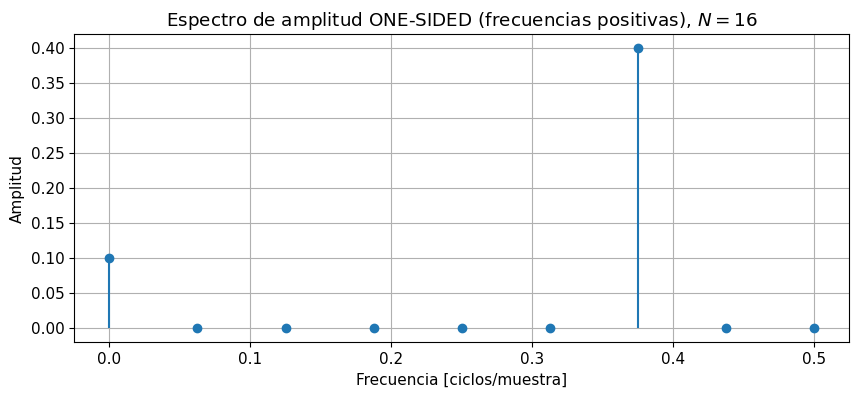

Amplitud del tono en bin k=6 (f=3/8): 0.4000
Amplitud esperada: 0.4 (amplitud original de la sinusoide)
Componente DC: 0.1000 (esperado: 0.1)


In [17]:
# === VALIDACIÓN ===
assert AfreqOneSided is not None, "Construye el espectro one-sided"
assert len(AfreqOneSided) == N // 2 + 1, f"El one-sided debe tener {N//2+1} muestras"

# Creamos el vector esperado según la fórmula:
AfreqOneSided_expected = Afreq[:N//2+1].copy()
AfreqOneSided_expected[1:-1] *= 2  # Duplicamos las amplitudes excepto DC y Nyquist
assert np.allclose(AfreqOneSided, AfreqOneSided_expected), (
    "AfreqOneSided no cumple la fórmula: debe ser igual a Afreqcompleto[:N//2+1], "
    "multiplicando por 2 todos los elementos salvo el primero (DC) y el último (Nyquist, si N par)"
)

# Compara AfreqOneSided y AfreqOneSided_rfft para verificar que son iguales
assert np.allclose(AfreqOneSided, AfreqOneSided_rfft), "Los dos espectros one-sided deben ser iguales"

print("rrft() proporciona el mismo resultado que el método manual")
print(f"AfreqOneSided = {AfreqOneSided}")
print(f"AfreqOneSided_rfft = {AfreqOneSided_rfft}")
print(f"ECMrrft = {ECMrrft}")


# === VISUALIZACIÓN ===
Fk_os = [Fraction(k, N) for k in range(0, N // 2 + 1)]
fk_os_float = [float(f) for f in Fk_os]

plt.figure(figsize=(10, 4))
plt.stem(Fk_os, AfreqOneSided, basefmt=' ')
plt.xlabel('Frecuencia [ciclos/muestra]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud ONE-SIDED (frecuencias positivas), $N = {N}$')
plt.show()

# Verificación de amplitudes
idx_tono = int(Fa / Fs * N)  # bin del tono
print(f"Amplitud del tono en bin k={idx_tono} (f={Fraction(idx_tono,N)}): {AfreqOneSided[idx_tono]:.4f}")
print(f"Amplitud esperada: {A} (amplitud original de la sinusoide)")
print(f"Componente DC: {AfreqOneSided[0]:.4f} (esperado: {C})")

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Por qué duplicamos las amplitudes de las frecuencias positivas (excepto DC y Nyquist)?**

*Tu respuesta:*

```
Porque en el espectro orginal (two-sided) cada frecuencia positiva tiene su pareja negativa y ambas contienen la mitad de la energía/amplitud. Al pasar a one-sided eliminamos las frecuencias negtaivas, por lo que para conservar la energía total del tono sinusoidal, debemos duplicar la amplitud de las frecuencias positivas (excepto DC y Nyquist) que no tienen pareja negativa.
```

**2. ¿La amplitud del tono en el one-sided coincide con la amplitud real $A$ de la sinusoide? ¿Y la componente DC con $C$?**

*Tu respuesta:*

```
Si coincide, la amplitud del tono en el one-sided será igual a A = 0.4, y la componente DC será igual a C = 0.1, ya que al duplicar las frecuencias positivas se recupera la amplitud física de la señal.
```

**3. ¿Por qué la representación one-sided es la más habitual en aplicaciones prácticas?**

*Tu respuesta:*

```
Porque:
- Elimina redundancia al mostrar solo frecuencias positivas.
- Es más fácil de interpretar, ya que las frecuencias negativas no aportan información adicional para señales reales.
- Es computacionalmente más eficiente, especialmente con funciones como rfft que calculan directamente el espectro one-sided.
```

### 🔍 Checkpoint del profesor (Parada 1)

- [ ] Señal $x(n)$ generada correctamente
- [ ] Espectro de amplitud (sin centrar) con picos identificados
- [ ] Espectro centrado con `fftshift` → deltas en $\pm 3/8$
- [ ] Espectro completo simétrico ($N+1$ muestras)
- [ ] Espectro one-sided con amplitudes recuperadas ($A = 0.4$, $C = 0.1$)

---

## Parte 6: La DFT y la frecuencia de muestreo $F_s$

### Contexto teórico

La FFT no interviene para nada la frecuencia de muestreo $F_s$. Para la DFT lo que cuenta es el número de puntos $N$. Somos nosotros quienes debemos interpretar la salida de acuerdo con $F_s$.

La correspondencia entre frecuencia normalizada $f_k$ y frecuencia en Hz $F_k$ es:

$$F_k = f_k \cdot F_s = \frac{k}{N} \cdot F_s$$

De esta forma:
- El intervalo $[0, 1)$ ciclos/muestra ↔ $[0, F_s)$ Hz
- El intervalo $[-1/2, 1/2)$ ciclos/muestra ↔ $[-F_s/2, F_s/2)$ Hz

La **resolución frecuencial** es:

$$\Delta F = \frac{F_s}{N} = \frac{1}{T_d}$$

donde $T_d = N / F_s$ es la duración de la ventana en segundos.

Por ejemplo, las $N$ muestras del espectro centrado en 0 de $x(n)$ se pueden ver en la siguiente imagen donde se muestran los valores de la frecuencia $f_k$ en ciclos/muestra y también los correspondientes a $F_k$ en Hz:

<img src="../helpers/fftshiftHz.svg" width="700"/>

---
### Representación en escala logarítmica

También es útil representar el espectro en **escala logarítmica (decibelios, dB)**:

$$A_{\text{dB}}(k) = 20 \cdot \log_{10}(A(k))$$

---

### Bloque 6 · Espectro en Hz y en dB

#### 📝 Hipótesis previa

**Preguntas:**

- Con $N = 16$ y $F_s = 8000$ Hz, ¿cuál es la resolución frecuencial $\Delta F$? 500 Hz (8000/16).
- ¿En qué frecuencia en Hz esperas ver el pico del tono? 3000 Hz (3/8 * 8000).

In [18]:
# === IMPLEMENTACIÓN ===

# TODO: Calcula la resolución frecuencial, DeltaF
DeltaF = Fs / N

# TODO: Calcula la duración de la ventana, Td
Td = N/Fs

# TODO: Calcula el espectro de amplituden dB, AdB
epsilon = 1e-12
AdB = 20 * np.log10(AfreqOneSided + epsilon)

In [23]:
# TODO: Calcula el eje de ordenadas en kHz, Fk_Hz usando linespace
Fk_Hz = np.linspace(-Fs/2, Fs/2, len(Afreqcompleto))
Fk_kHz = Fk_Hz / 1000

In [24]:
assert DeltaF == 1/Td, "No están bien calculadas DeltaF y Td"

print(f"N = {N} muestras")
print(f"Fs = {Fs} Hz")
print(f"Resolución frecuencial: ΔF = {DeltaF} Hz")
print(f"Duración de la ventana: Td = {Td*1e3} ms")

N = 16 muestras
Fs = 8000 Hz
Resolución frecuencial: ΔF = 500.0 Hz
Duración de la ventana: Td = 2.0 ms


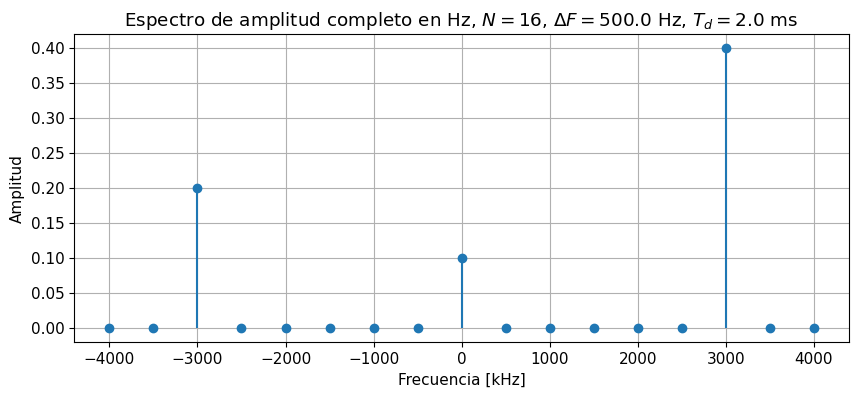

Pico del tono esperado en ±3.0 kHz


In [25]:
# === VISUALIZACIÓN: Espectro completo en Hz (escala lineal) ===
plt.figure(figsize=(10, 4))
plt.stem(Fk_Hz, Afreqcompleto, basefmt=' ')
plt.xlabel('Frecuencia [kHz]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud completo en Hz, $N = {N}$, $\\Delta F = {DeltaF}$ Hz, $T_d = {Td*1e3}$ ms')
plt.show()

print(f"Pico del tono esperado en ±{Fa/1e3} kHz")

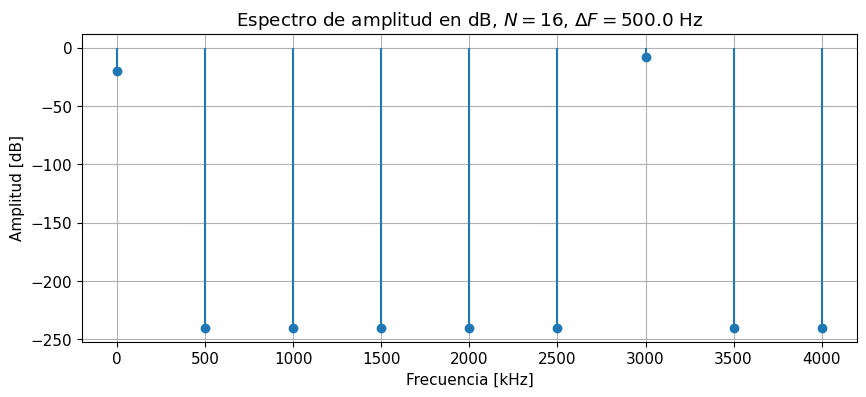

In [22]:
# === VALIDACIÓN ===
assert AdB is not None, "Calcula el espectro en dB"

plt.figure(figsize=(10, 4))
plt.stem(Fk_Hz, AdB, basefmt=' ')
plt.xlabel('Frecuencia [kHz]')
plt.ylabel('Amplitud [dB]')
plt.title(f'Espectro de amplitud en dB, $N = {N}$, $\\Delta F = {DeltaF}$ Hz')
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Qué determina la resolución frecuencial: $F_s$, $N$ o ambos?**

*Tu respuesta:*

```
La resoolución frecuencia depende de ambos, ya que se calcula como ΔF = Fs/N. Aumentar Fs o disminuir N mejora la resolución, mientras que disminuir Fs o aumentar N la empeora.
```

**2. ¿Qué diferencias fundamentales encuentras entre el espectro en escala lineal y logarítmica (dB)?**

*Tu respuesta:*

```
La escala lineal muestra amplitudes reales, los picos dominantes destacan mucho y las componentes pequeñas casi no se ven.

La escala logarítmica (en dB) comprime el rango dinámico y permite ver componentes débiles junto a las fuertes, facilitando la interpretación de señales con gran diferencia de amplitudes.
```

**3. ¿Es posible conocer el valor del espectro para una frecuencia arbitraria (por ejemplo, 3.2 kHz)? ¿Por qué?**

*Tu respuesta:*

```
No directamente, porque la DFT solo proporciona valores para frecuencias discretas determinadas por k/N * Fs. Para conocer el espectro en una frecuencia arbitraria como 3.2 kHz, se necesitaría interpolar entre los bins de la DFT o aumentar N para obtener una mayor resolución frecuencial.
```

**4. ¿Qué ventaja tiene la representación en decibelios?**

*Tu respuesta:*

```
Permite visualizar señakes con gran rango dinámico, ya que comprime las amplitudes y hace visibles componentes débiles que en escala lineal serían invisibles. 
```

---

## Parte 7: Propiedades de la DFT — Parseval y linealidad

### Bloque 7a · Propiedad de Parseval

La energía de una señal es la misma en el dominio del tiempo y en el de la frecuencia:

$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$



In [28]:
# === IMPLEMENTACIÓN: PARSEVAL ===
# TODO: Calcula la DFT de la señal x del bloque 2, X
X = np.fft.fft(xtime)

# TODO: Calcula la energía en tiempo, lado izquierdo de la propiedad de Parseval, E_tiempo
E_tiempo = np.sum(np.abs(xtime)**2)

# TODO: Calcula la energía en frecuencia, lado derecho de la propiedad de Parseval, E_freq
E_freq = (1/N) * np.sum(np.abs(X)**2)

In [29]:
# === VALIDACIÓN ===
assert E_tiempo is not None, "Calcula la energía en tiempo"
assert E_freq is not None, "Calcula la energía en frecuencia"
assert np.allclose(E_tiempo, E_freq), "Parseval no se cumple"

print(f"✓ PARSEVAL VERIFICADA")
print(f"Energía en tiempo: E_tiempo = {E_tiempo:.2e}")
print(f"Energía en frecuencia: E_freq = {E_freq:.2e}")

✓ PARSEVAL VERIFICADA
Energía en tiempo: E_tiempo = 1.44e+00
Energía en frecuencia: E_freq = 1.44e+00



### Bloque 7b · Propiedad de linealidad

$$\text{DFT}\{a \cdot x_1[n] + b \cdot x_2[n]\} = a \cdot \text{DFT}\{x_1[n]\} + b \cdot \text{DFT}\{x_2[n]\}$$

In [30]:
# === IMPLEMENTACIÓN: LINEALIDAD ===
# Señal 1: x del bloque 1
x1 = x
# Señal 2
F2=2000
A2=0.6
x2 = A2 * np.sin(2 * np.pi * F2/Fs * n)

# Combinación en tiempo
x_suma = x1 + x2

# TODO: Calcula la DFT de x_suma, X_suma
X_suma = np.fft.fft(x_suma)

# TODO: Calcula la DFT de x1 y x2, X1 y X2, respectivamente
X1 = np.fft.fft(x1)
X2 = np.fft.fft(x2)


# TODO: Calcula la DFT de la combinación lineal, X_suma_espectral
X_suma_espectral = X1 + X2

In [31]:
# === VALIDACIÓN LINEALIDAD ===
assert np.allclose(X_suma, X_suma_espectral), "Linealidad no se cumple"
ecm_suma = np.max(np.abs(X_suma - X_suma_espectral))

print(f"✓ LINEALIDAD VERIFICADA")
print(f"DFT(x1 + x2) vs DFT(x1) + DFT(x2)")
print(f"Error cuadrático medio: {ecm_suma:.2e}")

✓ LINEALIDAD VERIFICADA
DFT(x1 + x2) vs DFT(x1) + DFT(x2)
Error cuadrático medio: 2.30e-13


### ✍️ Explicación (OBLIGATORIA)

**1. ¿Por qué Parseval es importante para validar cálculos de DFT?**

*Tu respuesta:*

```
Porque permite verificar que la energía de la señal se conserva al pasar del dominio del tiempo al de la frecuencia. Es útil para validar que la DFT está bien calculada, detectar errores y confirmar la consistencia entre ambas representaciones.
```

**2. ¿Qué significa intuitivamente que la DFT sea una operación lineal?**

*Tu respuesta:*

```
Significa que la transformada de una suma de señales es igual a la suma de sus transformadas, y que la transformada de una señal escalada es igual a la transformada de la señal original escalada por el mismo factor. Esto facilita el análisis de señales complejas como combinaciones lineales de otras más simples.
```

---

## 🚀 Extensiones opcionales

### Extensión A: Eje de frecuencias con `fftfreq` vs `linspace`
Construye el eje de frecuencias de dos formas alternativas y comprueba que son equivalentes:
- Método 1: `np.fft.fftfreq(N, 1/Fs)`
- Método 2: `np.linspace(0, Fs - Fs/N, N)`

---

## Preguntas de control

### P1. ¿Qué hace `fftshift` y por qué la representación centrada es más natural?

*Tu respuesta:*

```
`fftshift` reorganiza las muestras del espectro para que la frecuencia 0 quede en el centro, con las frecuencias negativas a la izquierda y las positivas a la derecha. Esta representación es más natural porque refleja mejor la simetría de la DFT y facilita la interpretación de las frecuencias, especialmente cuando se analizan señales reales con componentes positivas y negativas.
```

---

### P2. ¿Por qué la FFT de una señal real presenta simetría conjugada?

*Tu respuesta:*

```
Porque la DFT de una señal real tiene la propiedad de que los coeficientes para las frecuencias negativas son el conjugado complejo de los coeficientes para las frecuencias positivas. Esto se debe a que la señal real no puede contener información independiente en las frecuencias negativas, lo que resulta en una simetría conjugada en el espectro.
```

---

### P3. ¿Por qué hay que normalizar el espectro para recuperar amplitudes?

*Tu respuesta:*

```
Porque la FFT no devuelve directamente las amplitudes físicas de las componentes sinusoidales, sino que devuelve valores que dependen del número de puntos N. Al normalizar por N, se obtiene un espectro de amplitud que refleja correctamente las amplitudes de las componentes de la señal, facilitando su interpretación física.
```

---

### P4. Si quieres ver mejor dos tonos cercanos, ¿qué debes cambiar?

*Tu respuesta:*

```
Debes aumentar la resolución frecuencial, lo que se puede lograr aumentando el número de puntos N o disminuyendo la frecuencia de muestreo Fs. Esto permitirá distinguir mejor los dos tonos cercanos en el espectro.
```

---

## ✅ Checklist final

- [ ] Run All sin errores
- [ ] Señal generada y visualizada con `stem()`
- [ ] Espectro de amplitud (sin centrar) en ciclos/muestra
- [ ] Espectro centrado con `fftshift`
- [ ] Espectro completo simétrico ($N+1$ muestras)
- [ ] Espectro one-sided con amplitudes correctas
- [ ] Espectro en Hz y en dB
- [ ] Propiedad de Parseval verificada
- [ ] Propiedad de linealidad verificada
- [ ] Todas las explicaciones completadas
- [ ] Preguntas de control respondidas

---

## 📚 Resumen de conceptos clave

| Concepto | Fórmula/Descripción |
|----------|--------------------|
| **DFT** | $X(k) = \sum_{n=0}^{N-1} x(n)\, e^{-j 2\pi k n / N}$ |
| **Espectro de amplitud** | $A(k) = \frac{1}{N}\|X(k)\|$ |
| **Frecuencia normalizada** | $f_k = k/N$ ciclos/muestra |
| **Frecuencia en Hz** | $F_k = f_k \cdot F_s = k \cdot \Delta F$ |
| **Resolución frecuencial** | $\Delta F = F_s / N = 1 / T_d$ |
| **Centrado** | `np.fft.fftshift()` reordena de $[0,1)$ a $[-1/2, 1/2)$ |
| **One-sided** | Solo frecuencias positivas, ×2 normalización |
| **Simetría conjugada** | Señales reales: $\|X(k)\| = \|X(N-k)\|$ |
| **Parseval (DFT estándar)** | $\sum_{n=0}^{N-1} \lvert x[n]\rvert^2 = \frac{1}{N} \sum_{k=0}^{N-1} \lvert X[k]\rvert^2$ |
| **Escala dB** | $A_{\text{dB}} = 20 \cdot \log_{10}(A)$ |

---

## 🔗 Conexión con Taller 8

En el Taller 8 veremos:
- **Resolución frecuencial y Leakage**
- **Smearing**
- **Zero-padding**
- **Ventanas**

---

## 📖 Referencias

- John G. Proakis, Dimitris G. Manolakis, *Digital Signal Processing: Principles, Algorithms, and Applications*, 3rd edition, Prentice Hall, 1996.
- Holton, T. (2021). *Digital Signal Processing: Principles and Applications*. Cambridge: Cambridge University Press.
- [Interpret FFT results — GaussianWaves](https://www.gaussianwaves.com/2015/11/interpreting-fft-results-obtaining-magnitude-and-phase-information/)
- [The Power Spectrum — Neil Robertson (dsprelated.com)](https://www.dsprelated.com/showarticle/1004.php)
- [DFT Frequency Resolution Explained (Wave Walker DSP)](https://www.wavewalkerdsp.com/2022/03/16/dft-frequency-resolution-explained/)

---

**Fin del Taller 7**